In [6]:
pip install pandas numpy matplotlib openpyxl


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
jupyter notebooks

SyntaxError: invalid syntax (596414815.py, line 1)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df1 = pd.read_csv("../data/index_1.csv")

In [11]:
df2 = pd.read_csv("../data/index_2.csv")

In [12]:
df = pd.concat([df1, df2])

In [13]:
df.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [14]:
df.tail()

,date,datetime,cash_type,card,money,coffee_name
257,2025-03-23,2025-03-23 14:55:46,cash,NaN,30.0,Cappuccino
258,2025-03-23,2025-03-23 15:15:36,card,NaN,25.0,Irish whiskey
259,2025-03-23,2025-03-23 17:59:25,card,NaN,28.0,Super chocolate
260,2025-03-23,2025-03-23 18:01:33,card,NaN,28.0,Vanilla with Irish whiskey
261,2025-03-23,2025-03-23 21:23:11,card,NaN,29.0,Coffee with Irish whiskey


In [15]:
df.shape

(3898, 6)

In [16]:
df.columns

Index(['date', 'datetime', 'cash_type', 'card', 'money', 'coffee_name'], dtype='str')

In [17]:
df.info

<bound method DataFrame.info of            date                 datetime cash_type                 card  \
0    2024-03-01  2024-03-01 10:15:50.520      card  ANON-0000-0000-0001   
1    2024-03-01  2024-03-01 12:19:22.539      card  ANON-0000-0000-0002   
2    2024-03-01  2024-03-01 12:20:18.089      card  ANON-0000-0000-0002   
3    2024-03-01  2024-03-01 13:46:33.006      card  ANON-0000-0000-0003   
4    2024-03-01  2024-03-01 13:48:14.626      card  ANON-0000-0000-0004   
..          ...                      ...       ...                  ...   
257  2025-03-23      2025-03-23 14:55:46      cash                  NaN   
258  2025-03-23      2025-03-23 15:15:36      card                  NaN   
259  2025-03-23      2025-03-23 17:59:25      card                  NaN   
260  2025-03-23      2025-03-23 18:01:33      card                  NaN   
261  2025-03-23      2025-03-23 21:23:11      card                  NaN   

     money                 coffee_name  
0     38.7                

In [18]:
df.describe()

,money
count,3898.00000
mean,31.38060
std,5.06461
min,15.00000
25%,27.92000
50%,32.82000
75%,35.76000
max,40.00000


In [19]:
df.isnull().sum()

date             0
datetime         0
cash_type        0
card           351
money            0
coffee_name      0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(2)

In [21]:
df=df.drop_duplicates()

In [22]:
df["money"].sum()

np.float64(122271.57999999999)

In [23]:
df["money"].mean()

np.float64(31.38387577002053)

In [24]:
df.to_csv("../data/coffee_sales_cleaned.csv",index=False)

In [25]:
df.columns

Index(['date', 'datetime', 'cash_type', 'card', 'money', 'coffee_name'], dtype='str')

In [26]:
df.isnull().sum()

date             0
datetime         0
cash_type        0
card           349
money            0
coffee_name      0
dtype: int64

In [27]:
print("Number of Transactions =", len(df))

Number of Transactions = 3896


In [28]:
coffee_sales = df.groupby("coffee_name")["money"].sum()

coffee_sales

coffee_name
Americano                     15437.26
Americano with Milk           25269.12
Americano with milk            1050.00
Cappuccino                    18514.14
Caramel                          22.00
Caramel coffee                   56.00
Caramel with Irish whiskey      224.00
Caramel with chocolate          112.00
Caramel with milk                75.00
Chocolate                        25.00
Chocolate with coffee           150.00
Chocolate with milk             324.00
Cocoa                          8678.16
Coffee with Irish whiskey       464.00
Coffee with chocolate            28.00
Cortado                        7534.86
Double Irish whiskey            336.00
Double chocolate                 25.00
Double espresso                  27.00
Double espresso with milk        64.00
Double ristretto                 27.00
Double vanilla                   47.00
Espresso                       3187.28
Hot Chocolate                 10172.46
Hot milkshake                    30.00
Irish whiskey

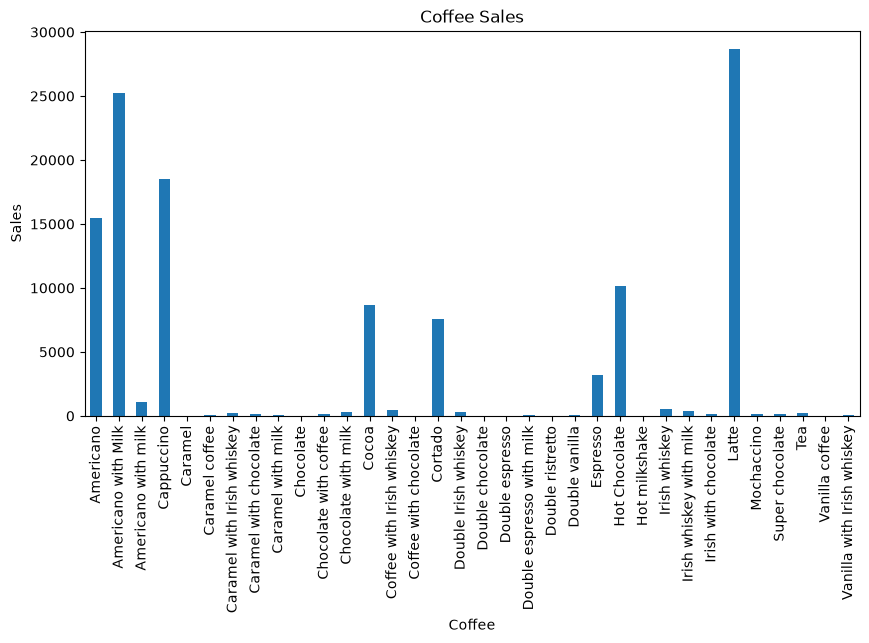

In [29]:
coffee_sales.plot(kind="bar", figsize=(10,5))

plt.title("Coffee Sales")

plt.xlabel("Coffee")

plt.ylabel("Sales")

plt.show()

In [30]:
payment = df["cash_type"].value_counts()

payment

cash_type
card    3729
cash     167
Name: count, dtype: int64

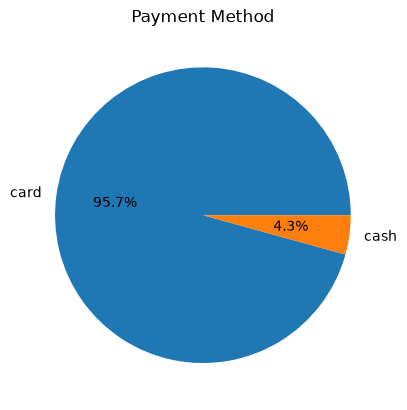

In [31]:
payment.plot(kind="pie", autopct="%1.1f%%")

plt.title("Payment Method")

plt.ylabel("")

plt.show()

In [32]:
df["date"] = pd.to_datetime(df["date"])

daily = df.groupby("date")["money"].sum()

daily

date
2024-03-01    396.30
2024-03-02    228.10
2024-03-03    349.10
2024-03-04    135.20
2024-03-05    338.50
               ...  
2025-03-19    763.56
2025-03-20    685.60
2025-03-21    741.80
2025-03-22    613.42
2025-03-23    394.76
Name: money, Length: 381, dtype: float64

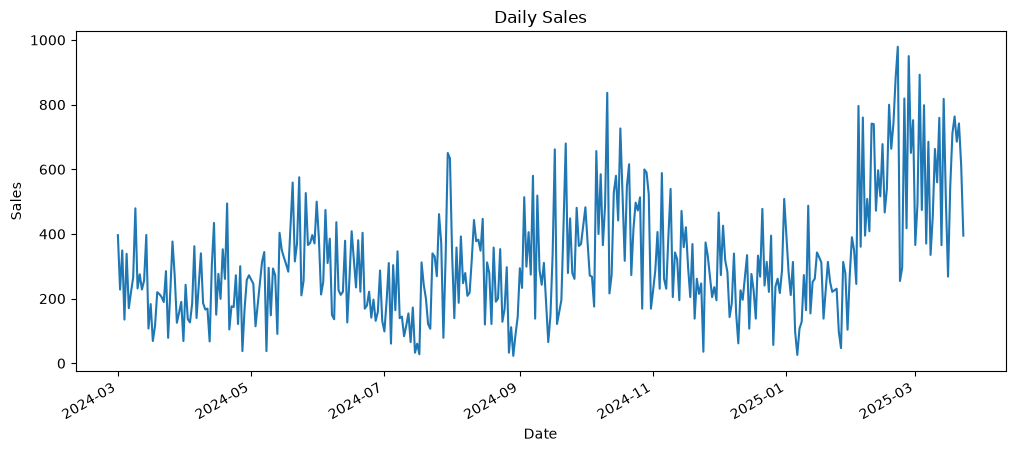

In [33]:
daily.plot(figsize=(12,5))

plt.title("Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [34]:
# Business Insights

- Total revenue was calculated from all coffee transactions.
- Coffee sales were analyzed by product.
- Payment methods (cash/card) were compared.
- Daily sales trends were visualized.
- The dataset was checked for missing values and duplicate records before analysis.

SyntaxError: invalid syntax (3461085978.py, line 3)

In [35]:
plt.savefig("../images/coffee_sales.png")
plt.show()


<Figure size 640x480 with 0 Axes>

In [36]:
payment = df["cash_type"].value_counts()

payment

cash_type
card    3729
cash     167
Name: count, dtype: int64

In [37]:
df.tail()

,date,datetime,cash_type,card,money,coffee_name
257,2025-03-23,2025-03-23 14:55:46,cash,NaN,30.0,Cappuccino
258,2025-03-23,2025-03-23 15:15:36,card,NaN,25.0,Irish whiskey
259,2025-03-23,2025-03-23 17:59:25,card,NaN,28.0,Super chocolate
260,2025-03-23,2025-03-23 18:01:33,card,NaN,28.0,Vanilla with Irish whiskey
261,2025-03-23,2025-03-23 21:23:11,card,NaN,29.0,Coffee with Irish whiskey


In [40]:
payment = df["cash_type"].value_counts()

payment

cash_type
card    3729
cash     169
Name: count, dtype: int64

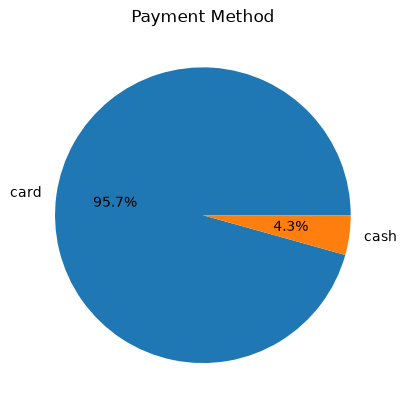

In [41]:
payment.plot(kind="pie", autopct="%1.1f%%")

plt.title("Payment Method")

plt.ylabel("")

plt.show()

In [42]:
df["date"] = pd.to_datetime(df["date"])

daily = df.groupby("date")["money"].sum()

daily

date
2024-03-01    396.30
2024-03-02    228.10
2024-03-03    349.10
2024-03-04    135.20
2024-03-05    338.50
               ...  
2025-03-19    763.56
2025-03-20    685.60
2025-03-21    741.80
2025-03-22    613.42
2025-03-23    419.76
Name: money, Length: 381, dtype: float64

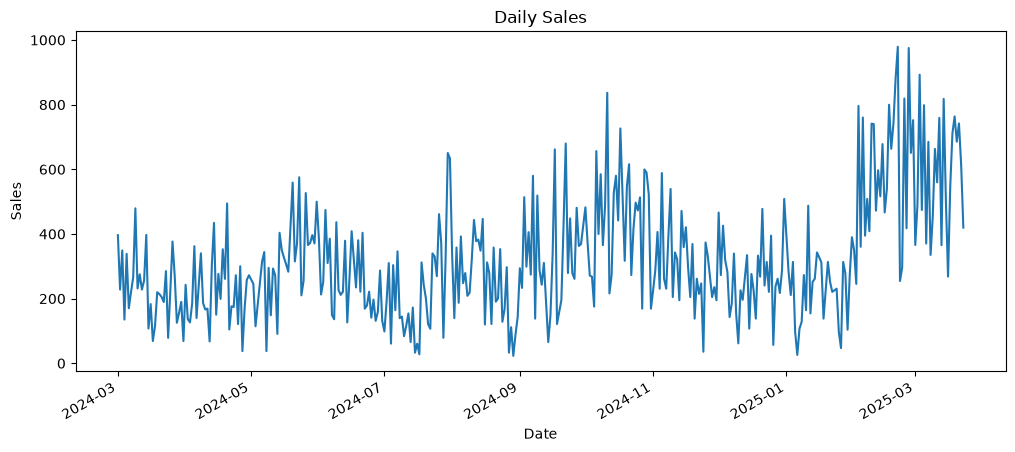

In [43]:
daily.plot(figsize=(12,5))

plt.title("Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [44]:
df.to_csv("../data/coffee_sales_cleaned.csv", index=False)

In [45]:
# Business Insights

- Total revenue was calculated from all coffee transactions.
- Coffee sales were analyzed by product.
- Payment methods (cash/card) were compared.
- Daily sales trends were visualized.
- The dataset was checked for missing values and duplicate records before analysis.

SyntaxError: invalid syntax (3461085978.py, line 3)

In [46]:
plt.savefig("../images/coffee_sales.png")
plt.show()

<Figure size 640x480 with 0 Axes>

In [47]:
plt.savefig("../images/payment_methods.png")
plt.show()

<Figure size 640x480 with 0 Axes>

In [48]:
plt.savefig("../images/daily_sales.png")
plt.show()

<Figure size 640x480 with 0 Axes>